In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats

from pathlib import Path

In [9]:
df = pd.read_csv("../data/west_states_filtered_v2.csv")

In [10]:
## IRQ Functions for outliers - created these during lab_02_todo
def get_iqr_upper(x):
    return x.quantile(0.75)+(1.5*(x.quantile(0.75)-x.quantile(0.25)))

def get_iqr_lower(x):
    iqr_low = x.quantile(0.25)-(1.5*(x.quantile(0.75)-x.quantile(0.25)))
    if iqr_low < 0:
        return 0
    else:
        return iqr_low

In [11]:
# Confirming columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543076 entries, 0 to 543075
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   VAERS_ID         543076 non-null  int64  
 1   symptom          543076 non-null  object 
 2   STATE            543076 non-null  object 
 3   AGE_YRS          543076 non-null  float64
 4   SEX              543076 non-null  object 
 5   DIED             543076 non-null  object 
 6   HOSPITAL         543076 non-null  object 
 7   ONSET_DATE       543076 non-null  object 
 8   TODAYS_DATE      541980 non-null  object 
 9   VAX_MANU         543076 non-null  object 
 10  VAX_DOSE_SERIES  543076 non-null  float64
 11  ONSET_YEAR       543076 non-null  float64
 12  ONSET_MONTHYEAR  543076 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 53.9+ MB


In [ ]:
## Removes unused columns due to Streamlit resource limitations
df.drop(columns=['Unnamed: 0','FORM_VERS','V_FUNDBY','V_ADMINBY','NUMDAYS','V_ADMINBY','V_FUNDBY','FORM_VERS','VAX_LOT','RECVDATE','VAX_DATE','RECOVD','DISABLE','HOSPDAYS','RPT_DATE'], inplace=True)
df.info()

In [ ]:
# (Extra) Dropping people without an AGE_YRS
df.dropna(axis=0, subset=['AGE_YRS'], inplace=True)
df.info()

In [ ]:
df["STATE"].unique()

In [ ]:
# (Extra) Dropping people without an VAX_DOSE_SERIES
df.dropna(axis=0, subset=['VAX_DOSE_SERIES'], inplace=True)
df.info()

In [ ]:
# (Extra) Dropping people without an ONSET_YEAR
df.dropna(axis=0, subset=['ONSET_YEAR'], inplace=True)
df.info()

In [ ]:
# (Extra) Only keeps west coast states
#df_coastal = df[df["STATE"].isin(["CA","WA","OR"])]
#df_coastal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543076 entries, 0 to 543075
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   VAERS_ID         543076 non-null  int64  
 1   symptom          543076 non-null  object 
 2   STATE            543076 non-null  object 
 3   AGE_YRS          543076 non-null  float64
 4   SEX              543076 non-null  object 
 5   DIED             543076 non-null  object 
 6   HOSPITAL         543076 non-null  object 
 7   ONSET_DATE       543076 non-null  object 
 8   TODAYS_DATE      541980 non-null  object 
 9   VAX_MANU         543076 non-null  object 
 10  VAX_DOSE_SERIES  543076 non-null  float64
 11  ONSET_YEAR       543076 non-null  float64
 12  ONSET_MONTHYEAR  543076 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 53.9+ MB
None

                    count          mean            std        min        25%  \
VAERS_ID         543076.0  1.552328

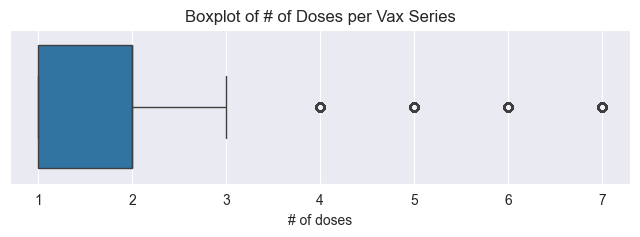

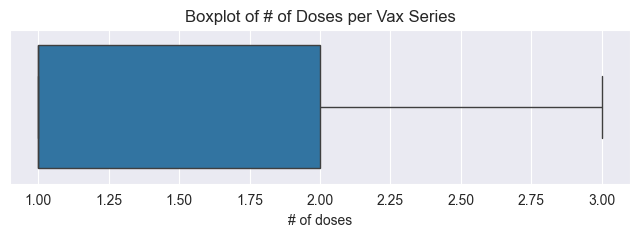

In [12]:
# Checking and removing outliers - grabbed from Brian's EDA

# Getting descriptive statistics of outliers for VAX_DOSE_SERIES
print(f'{df.info()}\n')
print(df.describe(percentiles=[0.25,0.5,0.75]).T)
print(f'\nUpper IQR: {get_iqr_upper(df['VAX_DOSE_SERIES'])}\n')

# Boxplot for VAX_DOSE_SERIES (visualizing outliers for VAX_DOSE_SERIES)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df, x= df['VAX_DOSE_SERIES'])
ax.set_xlabel('# of doses',fontsize = 10)
ax.set_title('Boxplot of # of Doses per Vax Series', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

# Dropping outliers - creating new DF that contains version of df_vax w/o int64 outliers. The get_iqr_upper function calculates upper bound of column and removes observations from outside that upper bound.
df_noliers = df[df['VAX_DOSE_SERIES']<(get_iqr_upper(df['VAX_DOSE_SERIES']))]
print(f'\n{df_noliers.info()}\n')
# NOTE: I am removing outliers from these as it seems bizarre to have COVID19 dose requirements in the 4-7 range. I could see it being possible, but again, it looks to fall outside the range of the typical.

# Boxplot for VAX_DOSE_SERIES (visualizing VAX_DOSE_SERIES w/o outliers)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_noliers, x= df_noliers['VAX_DOSE_SERIES'])
ax.set_xlabel('# of doses',fontsize = 10)
ax.set_title('Boxplot of # of Doses per Vax Series', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

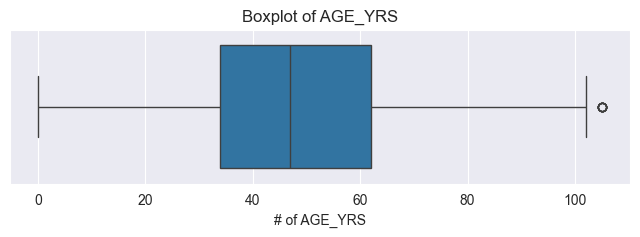

In [14]:
# Boxplot for Age (visualizing Age w/ outliers)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_noliers, x= df_noliers['AGE_YRS'])
ax.set_xlabel('# of AGE_YRS',fontsize = 10)
ax.set_title('Boxplot of AGE_YRS', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

## I literally see no point in removing the outlier of the few 105 years olds if the max quartile range goes over 100.

In [13]:
# Replaces west_states_filtered with reduced dataset
filepath = Path("../data/west_states_filtered_v2.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
df_noliers.to_csv(filepath, index=False)